# Worksheet 7 - Aranya Mukherjee(23MS261)

## Q1 (a)

In [264]:
import numpy as np
import matplotlib.pyplot as plt

In [266]:
#RK4 and caller-RK4 functions solve the differential equation using initial conditions y(a) and y'(a)(guessed) and finds solution for other point y(b).
#It's like shooting a projectile with known starting position and slope and guessing where it lands. 

# The following is standard RK4. It calls a function f(x,y,k) where k is a paramter
def rk4(f,x,y,k,h):
    k1 = h*f(x,y,k)
    k2 = h*f(x + h/2, y + k1/2, k)
    k3 = h*f(x + h/2, y + k2/2, k)
    k4 = h*f(x + h, y + k3, k)
    return y + (k1+2*k2+2*k3+k4)/6

# The following is a caller function. It integrates f from xlim[0] to xlim[1] with initial condition yini. 
# The parameter k is included in the argument along with the number of points N.
def caller_rk4(f,xlim,yini,k,N):
    x1, x2 = xlim
    xs = np.linspace(x1, x2, N)
    h = xs[1] - xs[0]
    y = yini
    ys = np.zeros((N,len(yini)))
    for i in range(N):
        ys[i] = np.array(y)
        y = rk4(f, xs[i], y, k, h)
    return xs, ys

# This is an implementation of the secant method used for finding the root of the function score. 
#It finds the root for score(E)=0. It keeps updating roots until |score|<tolerance. 
def secant(ks,f,method,ybound):
    k1, k2 = ks
    iter = 0
    while abs(method(k2,f,ybound))>tol and iter<maxiter:
        f1 = method(k1,f,ybound)
        f2 = method(k2,f,ybound)
        k1, k2 = k2, (f2*k1 - f1*k2)/(f2 - f1)
        iter += 1
        print(iter, k1, k2, method(k2,f,ybound))
    if iter == maxiter:
        return iter, None
    else:
        return iter, k2

In [268]:
# The rhs of Schoedinger equation (using vectorized form)
def odefun2(x,y,E):
    k2 = E - pot(x);
    return np.array([y[1], -k2 * y[0]]) 

# The potential
def pot(x):
    if abs(x)>1.0:
        return 0.0
    else:
        return -Vo*(1 - x**3)/2

#The score function evaluates how far the solution is from satisfying psi(x_max)=0
# The score. Note: we are integrating from the right and from the left and checking the difference at one of the turning points.
def score2(E,f,ybound):
    # Start from the left
    yini1 = (ybound[0], 1.0e-2);
    # psi_<
    xs1, ys1 = caller_rk4(odefun2,xlim,yini1,E,N)
    a = abs(xs1 + Lo);
    # find solution at x = Lo (left turning point)
    n1=np.where(a == np.min(a))[0][0]
    # Start from right
    yini2 = (ybound[1], 1.0e-2)
    # psi_>
    xs2, ys2 = caller_rk4(odefun2,xlim[-1::-1],yini2,E,N)
    a = abs(xs2 + Lo);
    # find solution at x = Lo (left turning point)
    n2=np.where(a == np.min(a))[0][0]
    # scale psi_>
    ys2 = ys1[n1][0]*ys2/ys2[n2][0]
    # return the difference of derivatives as score
    return ys1[n1][1] - ys2[n2][1]

In [270]:
Vo = 40.0
Lo = 1.0
xlim = (-3.0, 3.0)
ybound = (0.0, 0.0)
yini = (ybound[0], 0.1) 
N = 129
maxiter = 50
tol = 1.0e-5

In [272]:
Es = np.linspace(-Vo, 0, 1000);
scores = [score2(E, odefun2, ybound) for E in Es] #stores all the scores(deviations) for all E values

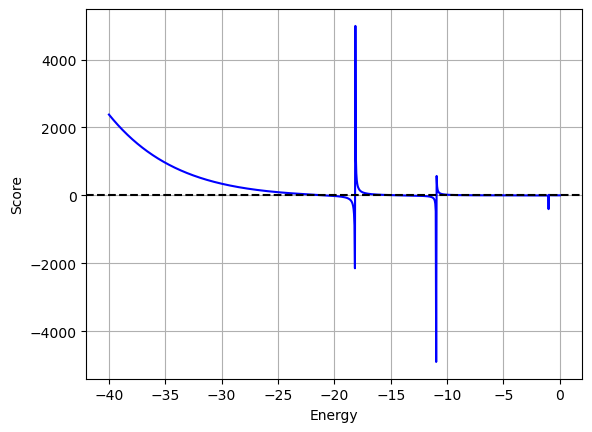

In [273]:
plt.plot(Es,scores,'b-');
plt.axhline(0, color='k', linestyle='--')
plt.grid()
plt.xlabel("Energy");
plt.ylabel("Score");
#From the score vs energy plot, eigenvalues are values of E for which score(E)=0. 
#NOT including the spikes which are divergences due to  ys2 = ys1[n1][0]*ys2/ys2[n2][0] line


(-23.0, -19.0)

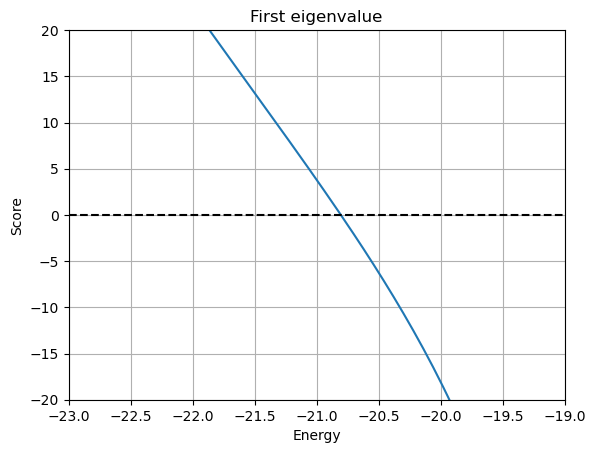

In [274]:
plt.plot(Es,scores);
plt.axhline(0, color='k', linestyle='--')
plt.grid()
plt.title("First eigenvalue")
plt.xlabel("Energy")
plt.ylabel("Score")
plt.ylim([-20.,20.])
plt.xlim([-23.0,-19.0])

In [275]:
Eini=(-21.0,-20.5)
iter,Eeigen = secant(Eini,odefun2,score2,ybound);

1 -20.5 -20.810725961420196 0.12006631182691052
2 -20.810725961420196 -20.80485852830329 0.00412781038641441
3 -20.80485852830329 -20.804649627454474 -2.365896655476263e-06


Text(0.5, 1.0, 'Eigenfunction for Bound State')

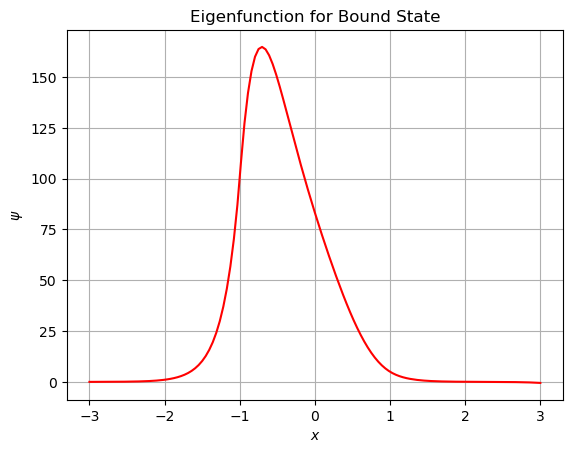

In [276]:
xs, ys = caller_rk4(odefun2, xlim, yini, Eeigen, N);
y1 = [y[0] for y in ys];
plt.plot(xs, y1,color="red");
plt.grid();
plt.xlabel("$x$")
plt.ylabel("$\\psi$")
plt.title("Eigenfunction for Bound State")

(-16.0, -10.0)

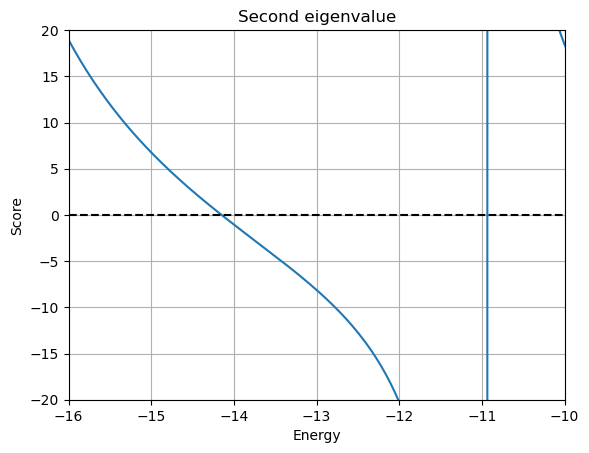

In [277]:
plt.plot(Es,scores);
plt.axhline(0, color='k', linestyle='--')
plt.grid()
plt.xlabel("Energy")
plt.title("Second eigenvalue")
plt.ylabel("Score");
plt.ylim([-20.,20.])
plt.xlim([-16,-10])

1 -14 -14.134656248915027 -0.10965745784333691
2 -14.134656248915027 -14.150346533531314 0.0012569574516927418
3 -14.150346533531314 -14.150168720574223 -1.6614898417088853e-06


Text(0.5, 1.0, 'Eigenfunction for Bound State')

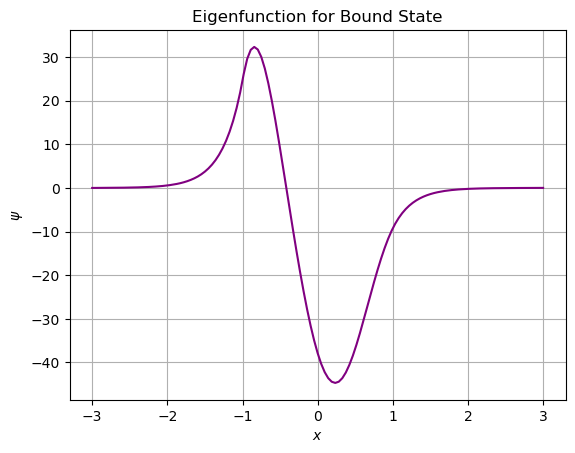

In [278]:
Eini=(-15,-14)
iter,Eeigen = secant(Eini,odefun2,score2,ybound);
xs, ys = caller_rk4(odefun2, xlim, yini, Eeigen, N);
y1 = [y[0] for y in ys];
plt.plot(xs, y1,color="purple");
plt.grid();
plt.xlabel("$x$")
plt.ylabel("$\\psi$")
plt.title("Eigenfunction for Bound State")

(-9.0, -2.0)

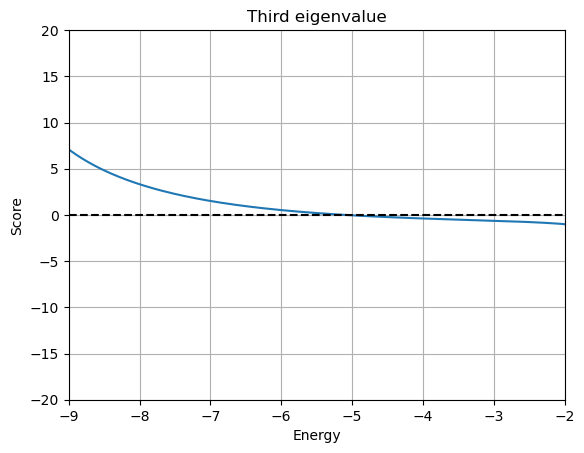

In [279]:
plt.plot(Es,scores)
plt.axhline(0, color='k', linestyle='--')
plt.grid()
plt.xlabel("Energy")
plt.title("Third eigenvalue")
plt.ylabel("Score");
plt.ylim([-20.,20.])
plt.xlim([-9,-2])

1 -4 -4.848696809957949 -0.10678497128870523
2 -4.848696809957949 -5.173484592006236 0.034072872430876144
3 -5.173484592006236 -5.09491990314965 -0.0021892667763154794
4 -5.09491990314965 -5.099663116508425 -4.1728618647929316e-05
5 -5.099663116508425 -5.099755281455858 5.2302105368884355e-08


Text(0.5, 1.0, 'Eigenfunction for Bound State')

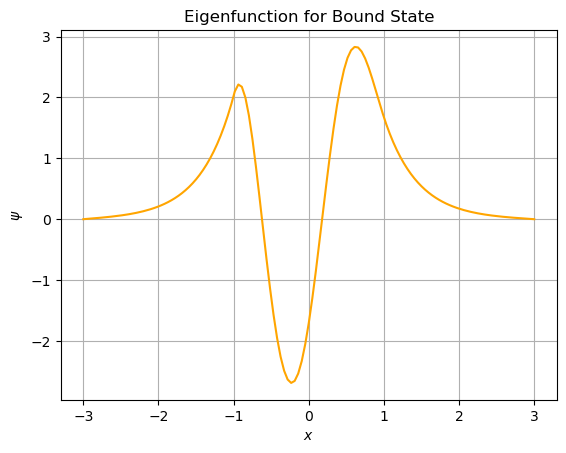

In [280]:
Eini=(-6,-4)
iter,Eeigen = secant(Eini,odefun2,score2,ybound);
xs, ys = caller_rk4(odefun2, xlim, yini, Eeigen, N);
y1 = [y[0] for y in ys];
plt.plot(xs, y1,color="orange");
plt.grid();
plt.xlabel("$x$")
plt.ylabel("$\\psi$")
plt.title("Eigenfunction for Bound State")

## Q1 (b)


In [282]:
def odefun3(x,y,E):
    k2 = E - x**2;
    return np.array([y[1], -k2 * y[0]]) 


#For normalization of wavefunction
def simp13(y,h):
    store = y[0]**2 + y[-1]**2
    for i in range(2,len(y)):
        if i%2==0:
            store += 4*y[i]**2
        else:
            store += 2*y[i]**2
    return store*(h/3)


In [283]:
def score3(E,f,ybound):
    xs, ys = caller_rk4(odefun3,xlim,yini,E,N)
    return ys[-1][0] - ybound[1]

In [284]:
xlim = (-5.0,5.0)
ybound = (0.0,0.0)
yini = (1e-5,0.0)

N = 400
maxiter = 50
tol = 1e-6

Text(0, 0.5, 'Score')

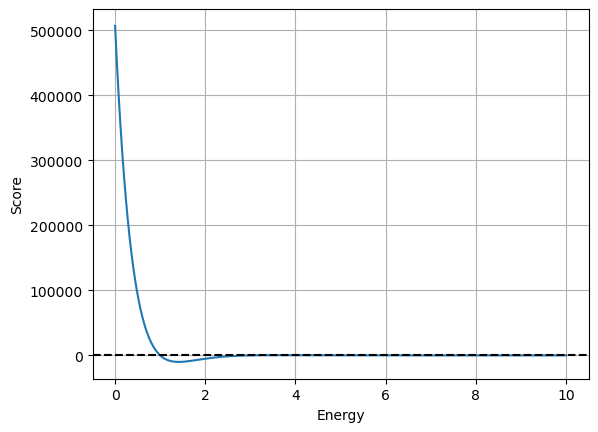

In [285]:
Es = np.linspace(0,10,500)
scores = [score3(E,odefun3,ybound) for E in Es]

plt.plot(Es,scores)
plt.axhline(0, color='k', linestyle='--')
plt.grid()
plt.xlabel("Energy")
plt.ylabel("Score")

In [286]:
Eguess = (0.5,1.2)

iter,Eeigen1 = secant(Eguess,odefun3,score3,ybound)
print(Eeigen1)

1 1.2 1.1441018363469355 -6631.910091228153
2 1.1441018363469355 0.8898760433244287 8962.680553880835
3 0.8898760433244287 1.0359872573518638 -2117.438725113369
4 1.0359872573518638 1.0080650360323202 -505.21499064307244
5 1.0080650360323202 0.9993151804874123 43.74683739376354
6 0.9993151804874123 1.0000124575806317 -0.7942949824273277
7 1.0000124575806317 1.0000000231483002 -0.0012146558585207064
8 1.0000000231483002 1.0000000041041308 3.380838555582855e-08
1.0000000041041308


Text(0, 0.5, 'psi')

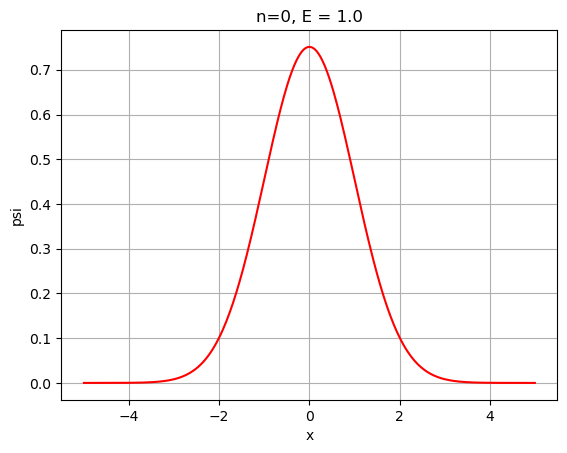

In [287]:
xs, ys = caller_rk4(odefun3,xlim,yini,Eeigen1,N)

h = xs[1]-xs[0]
psi = [y[0] for y in ys]

norm = simp13(psi,h)
psi = psi/np.sqrt(norm)

plt.plot(xs,psi,color="red")
plt.title("n=0, E = 1.0")
plt.grid()
plt.xlabel("x")
plt.ylabel("psi")

In [288]:
Eguess = (2.0,2.5)

iter,Eeigen2 = secant(Eguess,odefun3,score3,ybound)
print(Eeigen2)

1 2.5 2.693433454230274 -668.0033394338118
2 2.693433454230274 2.8605660972097486 -233.77413306297024
3 2.8605660972097486 2.9505445881675443 -71.46233766246559
4 2.9505445881675443 2.9901601520723045 -13.295476573588795
5 2.9901601520723045 2.999215270261344 -1.0440992705734369
6 2.999215270261344 2.9999869747042234 -0.017387777612552818
7 2.9999869747042234 3.000000043833504 -2.336273569164431e-05
8 3.000000043833504 3.0000000614172015 -5.232895028399712e-10
3.0000000614172015


Text(0, 0.5, 'psi')

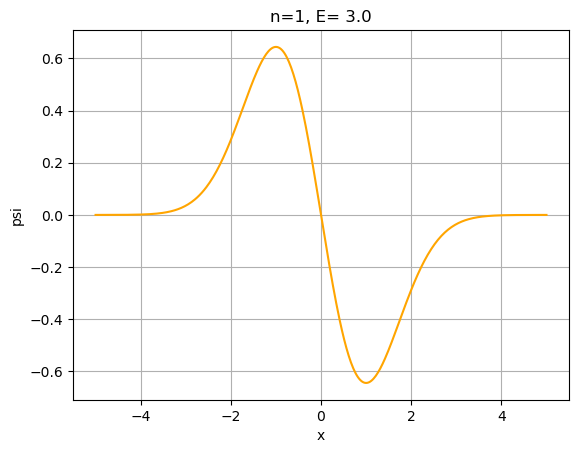

In [289]:
xs, ys = caller_rk4(odefun3,xlim,yini,Eeigen2,N)

h = xs[1]-xs[0]
psi = [y[0] for y in ys]

norm = simp13(psi,h)
psi = psi/np.sqrt(norm)

plt.plot(xs,psi,color="orange")
plt.title("n=1, E= 3.0")
plt.grid()
plt.xlabel("x")
plt.ylabel("psi")

In [290]:
Eguess = (3.5,5.5)

iter,Eeigen3 = secant(Eguess,odefun3,score3,ybound)
print(Eeigen3)

1 5.5 5.40560923013636 -12.317992503143643
2 5.40560923013636 3.1696167947935536 166.9375023243887
3 3.1696167947935536 5.251957382073691 -9.907059371104918
4 5.251957382073691 5.135301989161083 -6.397021954273773
5 5.135301989161083 4.922698241415254 4.9867830013651835
6 4.922698241415254 5.015831315937955 -0.8948390247580256
7 5.015831315937955 5.001661906681723 -0.09586902743183864
8 5.001661906681723 4.999961708314794 0.0022298219181500936
9 4.999961708314794 5.000000354431532 -5.346804925123024e-06
10 5.000000354431532 5.000000261985157 -2.9706223589015835e-10
5.000000261985157


Text(0, 0.5, 'psi')

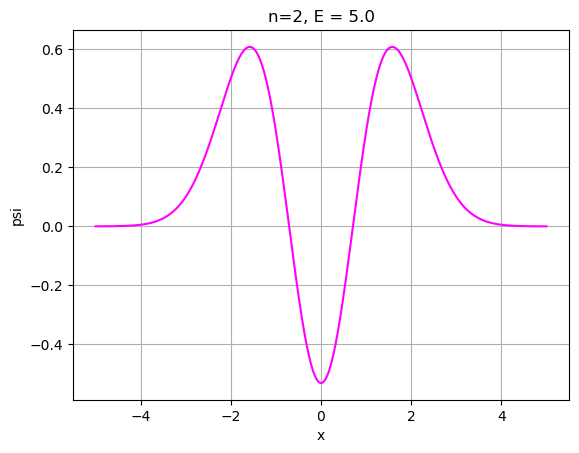

In [291]:
xs, ys = caller_rk4(odefun3,xlim,yini,Eeigen3,N)

h = xs[1]-xs[0]
psi = [y[0] for y in ys]

norm = simp13(psi,h)
psi = psi/np.sqrt(norm)

plt.plot(xs,psi,color="magenta")
plt.title("n=2, E = 5.0")
plt.grid()
plt.xlabel("x")
plt.ylabel("psi")

In [292]:
Eguess = (6.0,7.5)

iter,Eeigen4 = secant(Eguess,odefun3,score3,ybound)
print(Eeigen4)

1 7.5 7.357570717926219 0.862858897792967
2 7.357570717926219 6.137122591679501 -7.473908956027122
3 6.137122591679501 7.231253835473484 0.6720318156701957
4 7.231253835473484 7.1409891224150375 0.46442494577874005
5 7.1409891224150375 6.939063316733268 -0.2599095284820965
6 6.939063316733268 7.011519402710224 0.04493555269068787
7 7.011519402710224 7.000839045800239 0.0033148179856690267
8 7.000839045800239 6.999988425564209 -4.8321592048457975e-05
9 6.999988425564209 7.0000006472764165 5.067336193186862e-08
7.0000006472764165


Text(0, 0.5, 'psi')

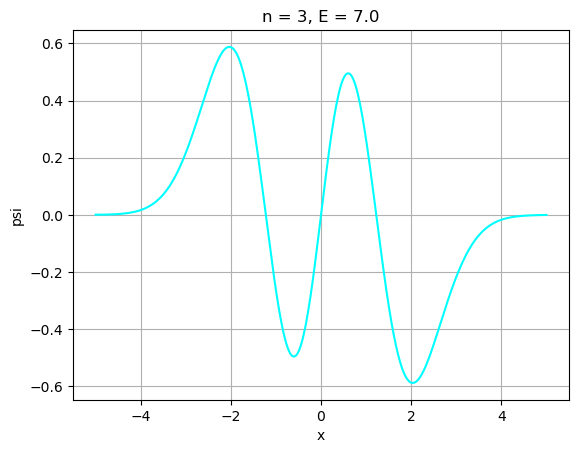

In [293]:
xs, ys = caller_rk4(odefun3,xlim,yini,Eeigen4,N)

h = xs[1]-xs[0]
psi = [y[0] for y in ys]

norm = simp13(psi,h)
psi = psi/np.sqrt(norm)

plt.plot(xs,psi,color="cyan")
plt.title("n = 3, E = 7.0")
plt.grid()
plt.xlabel("x")
plt.ylabel("psi")